In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from spatialmt.config import Paths, Dirs, setup_output_dirs, validate_raw_inputs

setup_output_dirs()
validate_raw_inputs()

In [ ]:
# load data
processed_tpm = pd.read_csv(Paths.processed_tpm, header=0, index_col=0)

Processed TPM data: (16763, 36)


In [ ]:
# subset data
mean_sd_cols = [c for c in processed_tpm.columns 
               if not c.startswith('H9')]
expr = processed_tpm[mean_sd_cols]

In [ ]:
# all the same as original Lancaster paper (missing TBR2 in data)
genes_of_interest = ['GATA3','CDH2','CDH1','VIM','TBR1'] 
# fibronectin, junction protein TJP1, 2x non-muscle myo2 gene, neurodev spectrin, actin gene
structural_genes_of_interest = ['FN1','TJP1','MYH9','MYH10','SPTAN1','ACTG1']
all_genes = genes_of_interest + structural_genes_of_interest

# subset rows 
subset_expr = expr[expr['hgnc_symbol'].isin(all_genes)]

In [13]:
subset_expr

,hgnc_symbol,meanH9_d5,sdH9_d5,meanH9_d7,sdH9_d7,meanH9_d8,sdH9_d8,meanH9_d10,sdH9_d10,meanH9_d15,sdH9_d15,meanH9_d20,sdH9_d20,meanH9_d30,sdH9_d30
gene_id,,,,,,,,,,,,,,,
ENSG00000184009,ACTG1,6444.922782,504.068975,7611.755423,996.089716,4563.822162,381.198213,6112.798664,1039.657130,7967.786788,900.937127,7930.035207,620.188195,9119.263769,539.951351
ENSG00000039068,CDH1,360.728343,44.594730,239.243840,43.019153,38.735990,16.069663,5.750160,3.138225,1.026943,0.474356,2.410616,1.238011,1.279774,0.448770
ENSG00000170558,CDH2,116.095223,46.981436,225.611377,67.551024,384.985311,16.371852,569.625858,72.746958,633.580206,52.463110,1093.572947,224.691115,495.930138,103.669724
ENSG00000115414,FN1,12.133013,3.445190,28.472611,6.865040,16.906349,2.344361,27.881626,3.479968,45.850135,2.463174,66.859228,15.437374,25.196723,7.734780
ENSG00000107485,GATA3,13.518789,11.736109,4.048732,3.055599,1.226311,0.854261,0.198472,0.176431,0.155098,0.135621,0.164402,0.091415,0.244387,0.078531
ENSG00000133026,MYH10,401.089749,71.405492,410.985869,28.840236,281.896184,20.933569,335.306669,20.599145,266.742264,13.871875,294.545928,23.147831,257.779228,2.712990
ENSG00000100345,MYH9,350.067553,84.505175,530.640096,26.123099,258.743093,49.984875,311.061129,19.938484,178.555859,20.223285,141.834939,13.465403,103.555371,11.642988
ENSG00000197694,SPTAN1,108.300007,24.154813,126.634100,5.409673,49.827937,4.956939,75.615628,3.465267,95.328083,6.035390,135.632696,15.337417,152.484516,16.535210
ENSG00000136535,TBR1,0.018849,0.004077,0.025295,0.025759,0.042679,0.041064,0.112441,0.145611,2.009146,0.880291,9.309870,2.881707,42.905439,3.679534


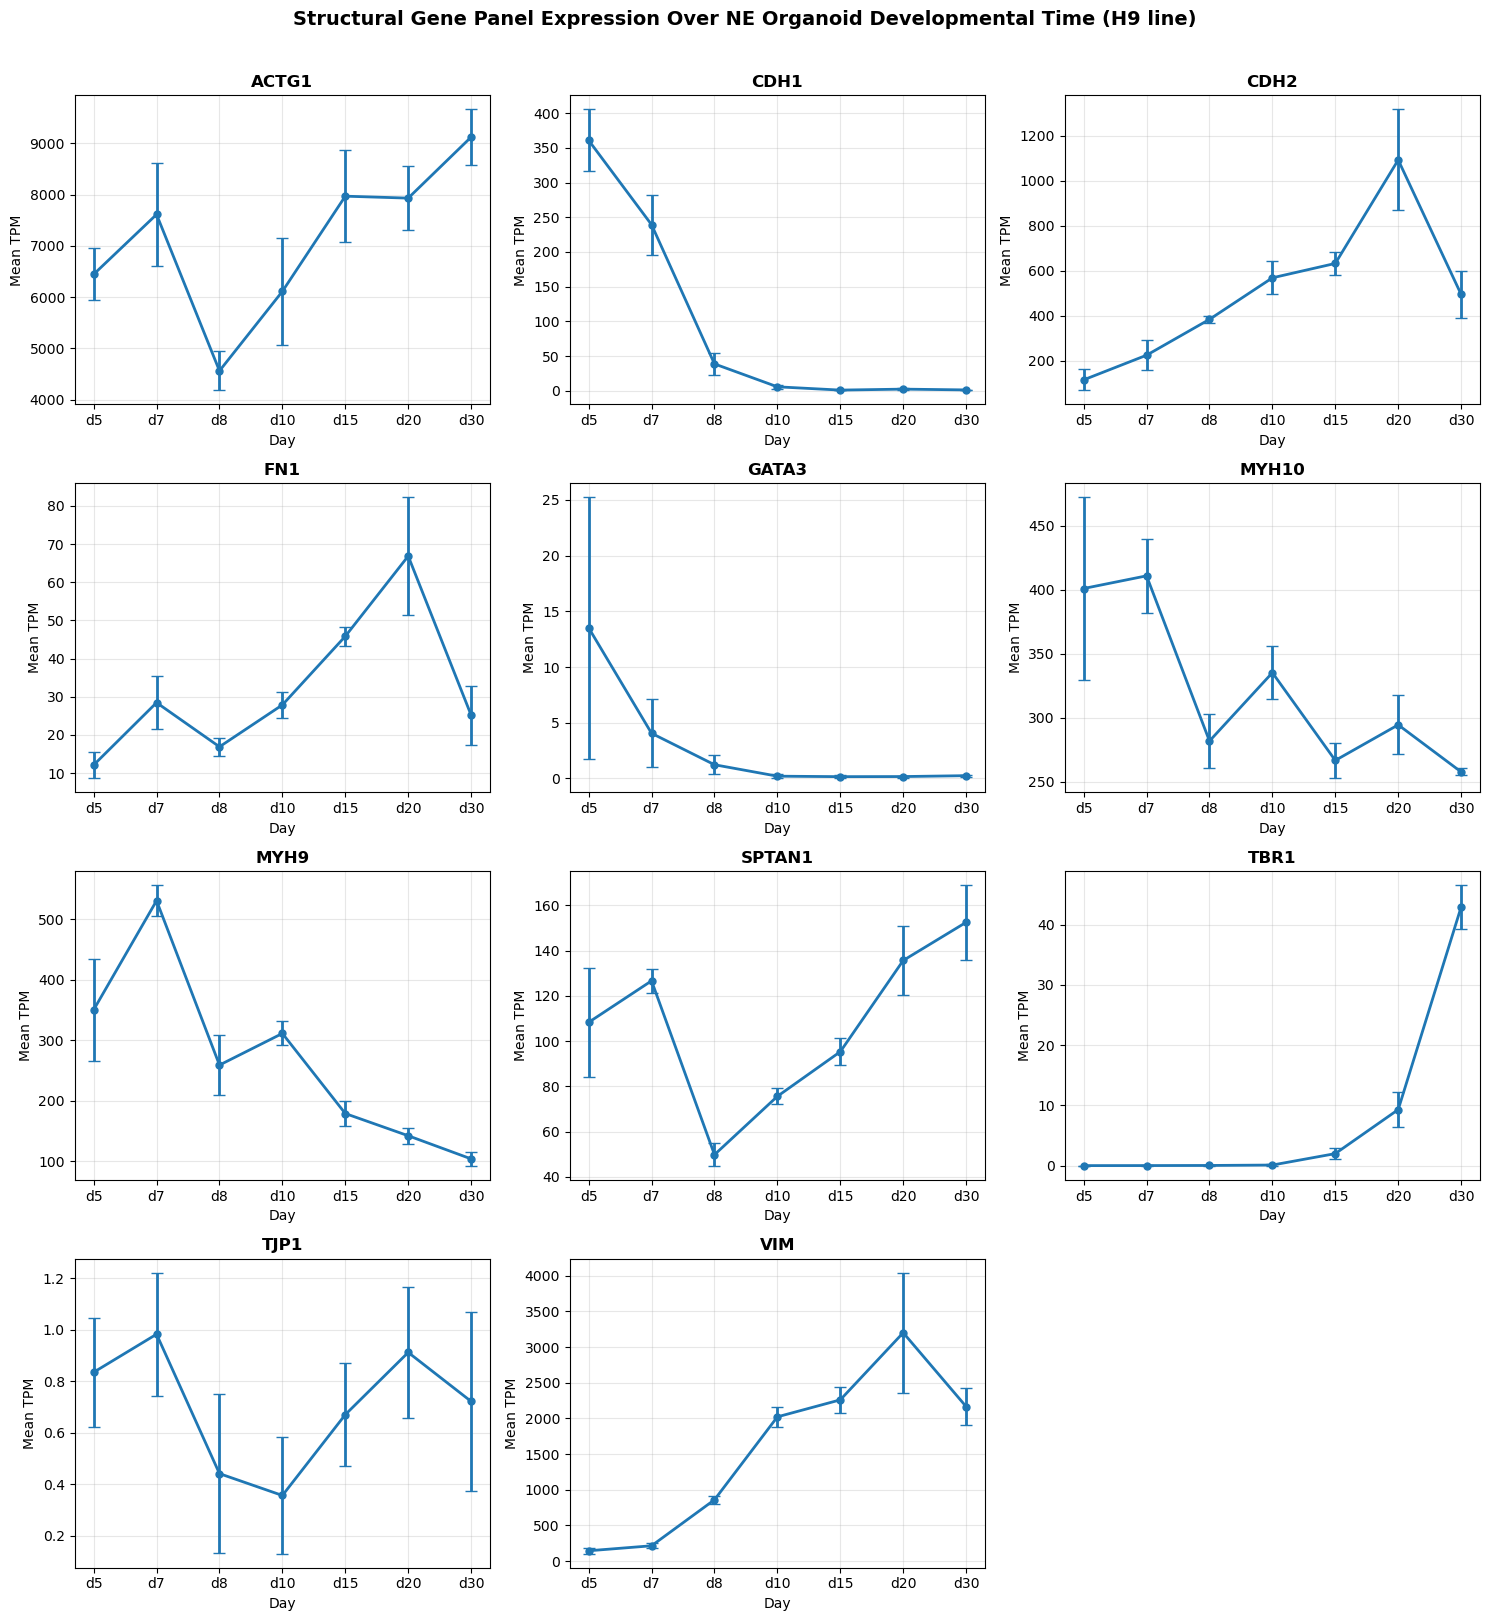

In [15]:
# time points in order
timepoints = ['d5', 'd7', 'd8', 'd10', 'd15', 'd20', 'd30']
mean_cols = [f'meanH9_{t}' for t in timepoints]
sd_cols   = [f'sdH9_{t}'   for t in timepoints]
x = np.arange(len(timepoints))

# 11 genes from subset_expr
genes = subset_expr['hgnc_symbol'].tolist()  

# line plotting 

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()  # easier to index

for i, (ax, gene) in enumerate(zip(axes, genes)):
    row = subset_expr[subset_expr['hgnc_symbol'] == gene].iloc[0]
    
    means = row[mean_cols].values.astype(float)
    sds   = row[sd_cols].values.astype(float)
    
    ax.errorbar(x, means, yerr=sds, fmt='-o', capsize=4, linewidth=2, markersize=5)
    ax.set_title(gene, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints)
    ax.set_xlabel('Day')
    ax.set_ylabel('Mean TPM')
    ax.grid(True, alpha=0.3)

# Hide the empty 12th subplot (4x3 grid = 12 slots, you have 11 genes)
axes[-1].set_visible(False)

plt.suptitle('Structural Gene Panel Expression Over NE Organoid Developmental Time (H9 line)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()